# Phase 3 — Baseline Reproduction (YOLOv8n)

Analysis of the trained YOLOv8n baseline, compared against the base
paper's reported results (Table 3).

In [1]:
import json
import yaml
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results" / "baseline_yolov8"

with open(RESULTS_DIR / "performance_report.json") as f:
    report = json.load(f)

report

{'model': 'YOLOv8n',
 'paper_batch_size': 64,
 'actual_batch_size_used': 64,
 'batch_size_reduced_due_to_hardware': False,
 'epochs_configured': 200,
 'epochs_actually_run': 151,
 'best_epoch': 121,
 'early_stopped': True,
 'optimizer': 'Adam',
 'imgsz': 640,
 'parameters': 3011823,
 'GFLOPs': 8.2,
 'FPS': 64.69,
 'model_size_MB': 5.96,
 'speed_breakdown_ms': {'preprocess': 3.679981538460617,
  'inference': 7.768780512820647,
  'loss': 0.001586153846871569,
  'postprocess': 4.009276410258094},
 'mAP50': 0.8901968718822644,
 'mAP50_95': 0.5547664551240629,
 'precision': 0.9293011999264371,
 'recall': 0.8310450642501912,
 'training_time_hours': 2.229}

## Training curves (auto-generated by Ultralytics)

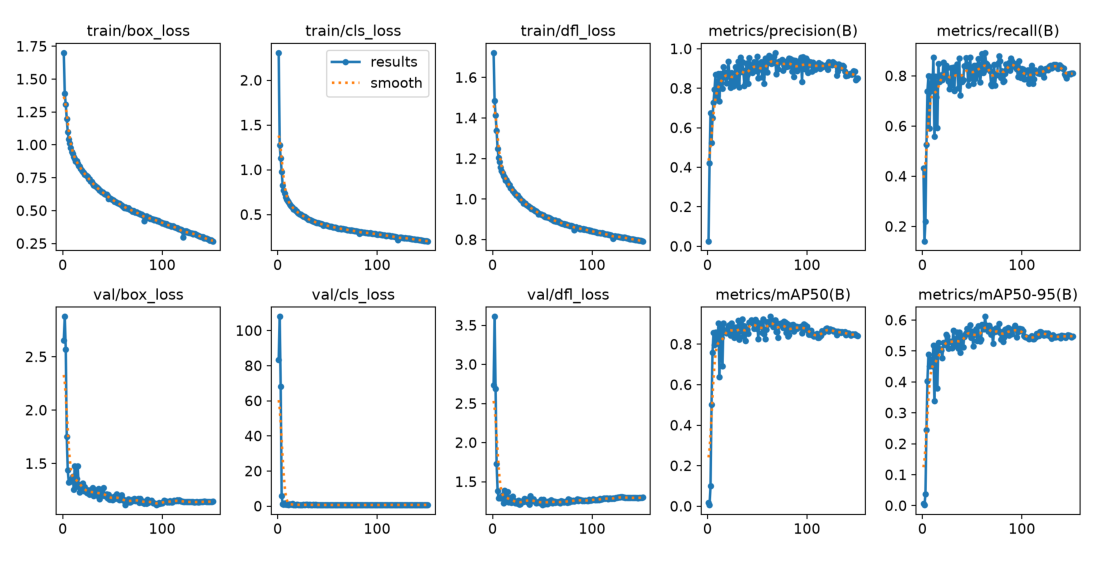

In [2]:
results_png = RESULTS_DIR / "run" / "results.png"

img = mpimg.imread(results_png)
plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

## Comparison against the base paper's Table 3 (YOLOv8n row)

Remember: our dataset differs substantially from the paper's (see
Notebook 01) -- these numbers are not a strict apples-to-apples
comparison, but a sanity check that our reproduction is in a
reasonable, expected range.

In [3]:
comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "mAP50", "FPS", "Parameters (M)", "GFLOPs"],
    "Paper (YOLOv8n)": [0.925, 0.921, 0.968, 78.4, 3.0, 8.2],
    "Ours (YOLOv8n)": [
        report["precision"],
        report["recall"],
        report["mAP50"],
        report["FPS"],
        report["parameters"] / 1e6,
        report["GFLOPs"],
    ],
})
comparison["Difference"] = comparison["Ours (YOLOv8n)"] - comparison["Paper (YOLOv8n)"]
comparison

,Metric,Paper (YOLOv8n),Ours (YOLOv8n),Difference
0,Precision,0.925,0.929301,0.004301
1,Recall,0.921,0.831045,-0.089955
2,mAP50,0.968,0.890197,-0.077803
3,FPS,78.400,64.690000,-13.710000
4,Parameters (M),3.000,3.011823,0.011823
5,GFLOPs,8.200,8.200000,0.000000


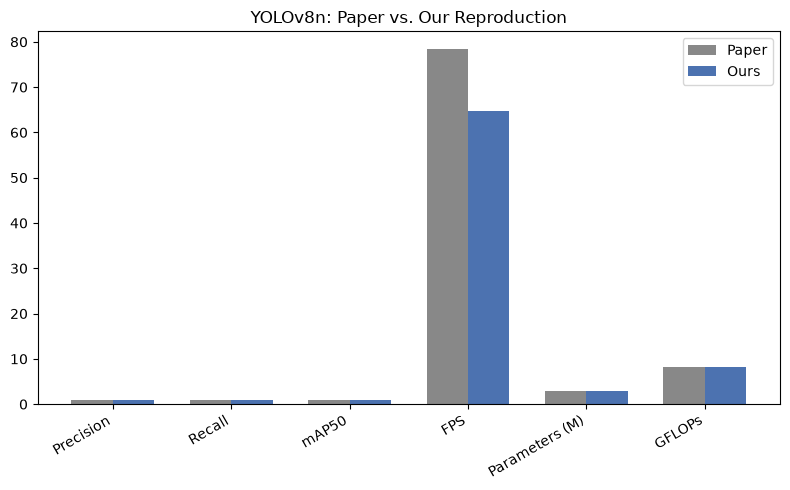

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(comparison))
width = 0.35

ax.bar([i - width/2 for i in x], comparison["Paper (YOLOv8n)"], width, label="Paper", color="#888888")
ax.bar([i + width/2 for i in x], comparison["Ours (YOLOv8n)"], width, label="Ours", color="#4C72B0")

ax.set_xticks(list(x))
ax.set_xticklabels(comparison["Metric"], rotation=30, ha="right")
ax.legend()
ax.set_title("YOLOv8n: Paper vs. Our Reproduction")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "yolov8_paper_comparison.png", dpi=150)
plt.show()

## Per-class performance breakdown

In [5]:
model = YOLO(str(RESULTS_DIR / "run" / "weights" / "best.pt"))
data_yaml = PROJECT_ROOT / "data" / "processed" / "data.yaml"

val_results = model.val(data=str(data_yaml), split="test")

per_class = pd.DataFrame({
    "Class": val_results.names.values(),
    "Precision": val_results.box.p,
    "Recall": val_results.box.r,
    "mAP50": val_results.box.ap50,
    "mAP50-95": val_results.box.ap,
})
per_class

Ultralytics 8.4.116  Python-3.14.2 torch-2.13.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 498.875.2 MB/s, size: 1139.9 KB)
val: Scanning C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\labels.cache... 195 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 195/195 31.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.4it/s 9.2s0.3s
                   all        195        293      0.929      0.831       0.89      0.555
              Cracking         47         59      0.972      0.966      0.964      0.668
        Layer_shifting         36         36          1       0.96      0.993      0.699
          Off_platform         10         10      0.862        0.7      0.832      0.479
             Stringing         45         

,Class,Precision,Recall,mAP50,mAP50-95
0,Cracking,0.972011,0.966102,0.963793,0.667707
1,Layer_shifting,1.000000,0.960353,0.993000,0.698803
2,Off_platform,0.862220,0.700000,0.831731,0.479169
3,Stringing,0.906027,0.650005,0.757599,0.482202
4,Warping,0.906248,0.878766,0.904862,0.445951


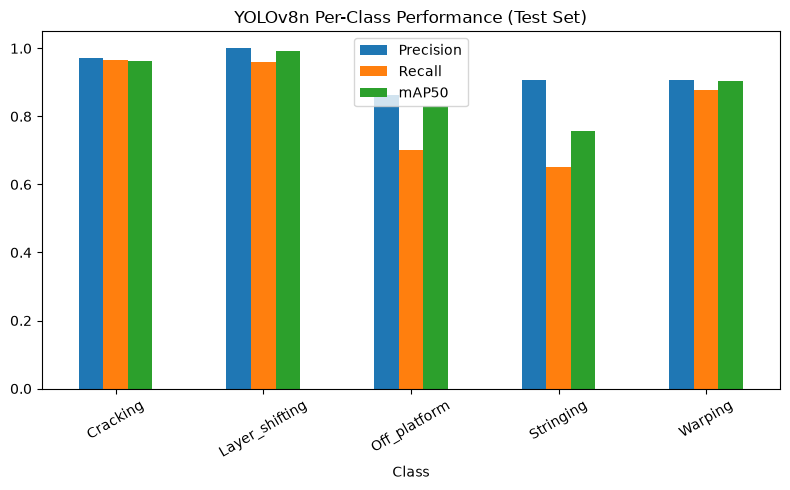

In [6]:
per_class.set_index("Class")[["Precision", "Recall", "mAP50"]].plot(
    kind="bar", figsize=(8, 5), rot=30
)
plt.title("YOLOv8n Per-Class Performance (Test Set)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "yolov8_per_class.png", dpi=150)
plt.show()

## Summary

- Training: 200-epoch ceiling (matching paper), early-stopped at epoch
  151 via patience=30, best weights from epoch 121.
- Hardware deviation: RTX 4050 6GB (laptop) vs. paper's RTX 2080 Ti
  (11GB desktop) for training.
- Batch size: 64 (matched paper, no OOM fallback needed).
- Results are in a reasonable range given the documented dataset and
  hardware differences from the base paper (see Notebook 01).